# Week 6

In [1]:
# Change kernel (on the right-top of Jupyter lab) to 'Python (ibl)'
# Alyx password for "intbrainlab" is: international

from one.api import ONE
one = ONE()
eid = '4ecb5d24-f5cc-402c-be28-9d0f7cb14b3a'
trials = one.load_object(eid, 'trials', collection='alf')

Param ALYX_URL, current value is ["https://openalyx.internationalbrainlab.org"]: https://openalyx.internationalbrainlab.org
Param ALYX_LOGIN, current value is ["intbrainlab"]: intbrainlab
Param HTTP_DATA_SERVER, current value is ["https://ibl.flatironinstitute.org/public"]: https://ibl.flatironinstitute.org/public
Param HTTP_DATA_SERVER_LOGIN, current value is ["None"]: None
Enter the FlatIron HTTP password for None (leave empty to keep current):  ········
Enter the location of the download cache, current value is ["C:\Users\baipi\Downloads\ONE\openalyx.internationalbrainlab.org"]: F:\academic\ONE\openalyx.internationalbrainlab.org
Would you like to set this URL as the default one? [Y/n] Y
Are the above settings correct? [Y/n] Y


ONE Parameter files location: C:\Users\baipi\AppData\Roaming\.one


Enter Alyx password for "intbrainlab": ········


Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


E:\Anaconda\envs\ibl\Lib\site-packages\one\util.py:464: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
(S3) F:\academic\ONE\openalyx.internationalbrainlab.org\hoferlab\Subjects\SWC_043\2020-09-21\001\alf\_ibl_trials.goCueTrigger_times.npy: 100%|██████████| 4.36k/4.36k [00:00<00:00, 8.81kB/s]
(S3) F:\academic\ONE\openalyx.internationalbrainlab.org\hoferlab\Subjects\SWC_043\2020-09-21\001\alf\_ibl_trials.intervals_bpod.npy: 100%|██████████| 8.59k/8.59k [00:00<00:00, 17.4kB/s]
(S3) F:\academic\ONE\openalyx.internationalbrainlab.org\hoferlab\Subjects\SWC_043\2020-09-21\001\alf\_ibl_trials.quiescencePeriod.npy: 100%|██████████| 4.36k/4.36k [00:00<00:00, 8.77kB/s]
(S3) F:\academic\ONE\openalyx.internationalbrainlab.org\hoferlab\Subjects\SWC_043\2020-09-21\001\alf\#2025-03-03#\_ibl_trials.stimOffTrigger_times.npy: 100%|██████████| 4.36k/4.36k [00:00<00:00, 7.50kB/s]
(S3) F:\academic\ONE\openalyx.internationalbrainlab.org\

### Example 1. Computing behavioral performance

In [2]:
from brainbox.behavior.training import compute_performance

# compute performance
performance, contrasts, n_contrasts = compute_performance(trials)

# compute performance expressed as probability of choosing right
performance, contrasts, n_contrasts = compute_performance(trials, prob_right=True)

# compute performance during 0.8 biased block
performance, contrasts, n_contrasts = compute_performance(trials, block=0.8)

Matplotlib is building the font cache; this may take a moment.


### Example 2. Filtering trials

In [3]:
from brainbox.task.trials import find_trial_ids

# find index for stim right trials ordered by trial number
trial_id, _ = find_trial_ids(trials, side='right', choice='all', order='trial num')

# find index for correct, stim left, 100% contrast trials ordered by reaction time
trial_id, _ = find_trial_ids(trials, side='left', choice='correct', contrast=[1], order='reaction time')

# find index for correct trials ordered by trial number sorted by stimulus side
trial_id, _ = find_trial_ids(trials, side='left', choice='correct', order='reaction time', sort='side')

### Example 3. Plotting psychometric curve

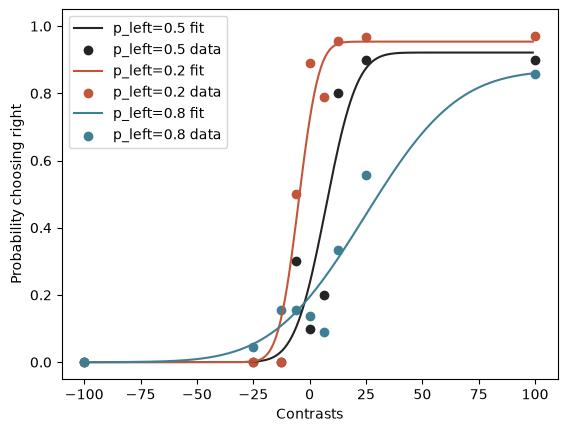

In [4]:
from brainbox.behavior.training import plot_psychometric

fig, ax = plot_psychometric(trials)

### Example 4. Simple data preview

Show a quick table preview of the loaded `trials` object plus a couple of simple summary plots.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

trial_preview_df = pd.DataFrame({k: np.asarray(v) for k, v in trials.items()})
display(trial_preview_df.head(10))
print('n_trials:', len(trial_preview_df))
print('columns:', list(trial_preview_df.columns))


In [ ]:
reaction_time = np.asarray(trials['feedback_times']) - np.asarray(trials['goCue_times'])
valid_rt = reaction_time[np.isfinite(reaction_time) & (reaction_time >= 0)]
signed_contrast = np.nan_to_num(np.asarray(trials['contrastRight']), nan=0.0) - np.nan_to_num(np.asarray(trials['contrastLeft']), nan=0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(signed_contrast, marker='o', markersize=2, linewidth=0.8, alpha=0.8)
axes[0].set_title('Signed Contrast by Trial')
axes[0].set_xlabel('trial index')
axes[0].set_ylabel('contrastRight - contrastLeft')
axes[0].grid(alpha=0.25)

axes[1].hist(valid_rt, bins=30, color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Reaction Time Distribution')
axes[1].set_xlabel('feedback_time - goCue_time (s)')
axes[1].set_ylabel('count')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
summary_df = pd.DataFrame({
    'choice': np.asarray(trials['choice']),
    'feedbackType': np.asarray(trials['feedbackType']),
    'probabilityLeft': np.asarray(trials['probabilityLeft']),
})
display(summary_df.groupby(['probabilityLeft', 'feedbackType']).size().rename('n_trials').reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_df['choice'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Choice Counts')
axes[0].set_xlabel('choice code')
axes[0].set_ylabel('count')
axes[0].grid(axis='y', alpha=0.25)

summary_df['feedbackType'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Feedback Counts')
axes[1].set_xlabel('feedbackType')
axes[1].set_ylabel('count')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()
